# 📊 Phase 3 — EDA on Cleaned Salary Dataset

## Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

# ── Paths ──────────────────────────────────────────────────────
PROJECT_ROOT   = Path("..").resolve()
CLEAN_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "salary_cleaned.csv"
OUTPUT_DIR      = PROJECT_ROOT / "eda_outputs" / "cleaned"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root  :", PROJECT_ROOT)
print("Clean Data    :", CLEAN_DATA_PATH)
print("Output Dir    :", OUTPUT_DIR)

assert CLEAN_DATA_PATH.exists(), f"❌ File not found: {CLEAN_DATA_PATH}"
print("\n✓ Cleaned data file found")

Project Root  : D:\study_material\ProjectFinal\salary_range_prediction
Clean Data    : D:\study_material\ProjectFinal\salary_range_prediction\data\processed\salary_cleaned.csv
Output Dir    : D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned

✓ Cleaned data file found


## Load Cleaned Dataset

In [2]:
_df = pd.read_csv(CLEAN_DATA_PATH)
print("Shape:", _df.shape)
_df.head()

Shape: (5074, 28)


,Job ID,Agency,Posting Type,# Of Positions,Business Title,Civil Service Title,Title Classification,Level,Job Category,Full-Time/Part-Time indicator,...,Salary Spread,Is Full Time,Is External,Career Level Encoded,Job Category Encoded,Agency Encoded,Borough Encoded,Title Seniority Encoded,Title Classification Encoded,Posting Type Encoded
0,623668,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Research Analyst, IMAT, Bureau of Maternal Inf...",CITY RESEARCH SCIENTIST,Non-Competitive-5,2,Constituent Services & Community Programs Heal...,F,...,12376.0,1,1,3,105,22,3,6,3,0
1,608193,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Deputy Director,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,0,"Policy, Research & Analysis Public Safety, Ins...",F,...,75888.0,1,0,3,167,20,4,0,0,1
2,625094,DEPT OF DESIGN & CONSTRUCTION,Internal,1,Senior Project Manager,ADMINISTRATIVE PROJECT MANAGER,Competitive-1,0,"Engineering, Architecture, & Planning",F,...,32723.0,1,0,3,123,20,4,3,0,1
3,580593,DEPARTMENT OF TRANSPORTATION,External,1,Procurement Analyst 2,PROCUREMENT ANALYST,Competitive-1,2,"Finance, Accounting, & Procurement",F,...,31758.0,1,1,3,135,18,3,6,0,0
4,624937,DEPT OF HEALTH/MENTAL HYGIENE,External,1,"Deputy Director, HIV Planning Council, Divisio...",CITY RESEARCH SCIENTIST,Non-Competitive-5,3,Constituent Services & Community Programs Heal...,F,...,13845.0,1,1,3,105,22,3,0,3,0


## 1. Basic Information

In [3]:
print("Shape:", _df.shape)
print("\nColumns:\n", _df.columns.tolist())
print("\nData Types:\n")
print(_df.dtypes)

Shape: (5074, 28)

Columns:
 ['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Classification', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Work Location', 'Division/Work Unit', 'Residency Requirement', 'Salary From Annual', 'Salary To Annual', 'Title Seniority', 'Borough', 'Salary Spread', 'Is Full Time', 'Is External', 'Career Level Encoded', 'Job Category Encoded', 'Agency Encoded', 'Borough Encoded', 'Title Seniority Encoded', 'Title Classification Encoded', 'Posting Type Encoded']

Data Types:

Job ID                             int64
Agency                            object
Posting Type                      object
# Of Positions                     int64
Business Title                    object
Civil Service Title               object
Title Classification              object
Level                             object
Job Category                      object
Full-Time/Part-Time indicator     object
C

## 2. Dataset Summary

In [4]:
_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Job ID,5074.0,NaN,NaN,NaN,598844.05065,28099.689218,469953.0,586766.75,607063.0,621375.25,628806.0
Agency,5074,59,DEPT OF ENVIRONMENT PROTECTION,926,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Posting Type,5074,2,Internal,2578,NaN,NaN,NaN,NaN,NaN,NaN,NaN
# Of Positions,5074.0,NaN,NaN,NaN,2.057548,5.757796,1.0,1.0,1.0,1.0,150.0
Business Title,5074,1771,Project Manager,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Civil Service Title,5074,364,COMMUNITY COORDINATOR,269,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Title Classification,5074,5,Competitive-1,3314,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Level,5074,18,0,2076,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Job Category,5074,183,"Engineering, Architecture, & Planning",782,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Full-Time/Part-Time indicator,5074,2,F,4912,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Missing Values Analysis

In [5]:
missing = _df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print(missing if len(missing) > 0 else "✓ No missing values found")

✓ No missing values found


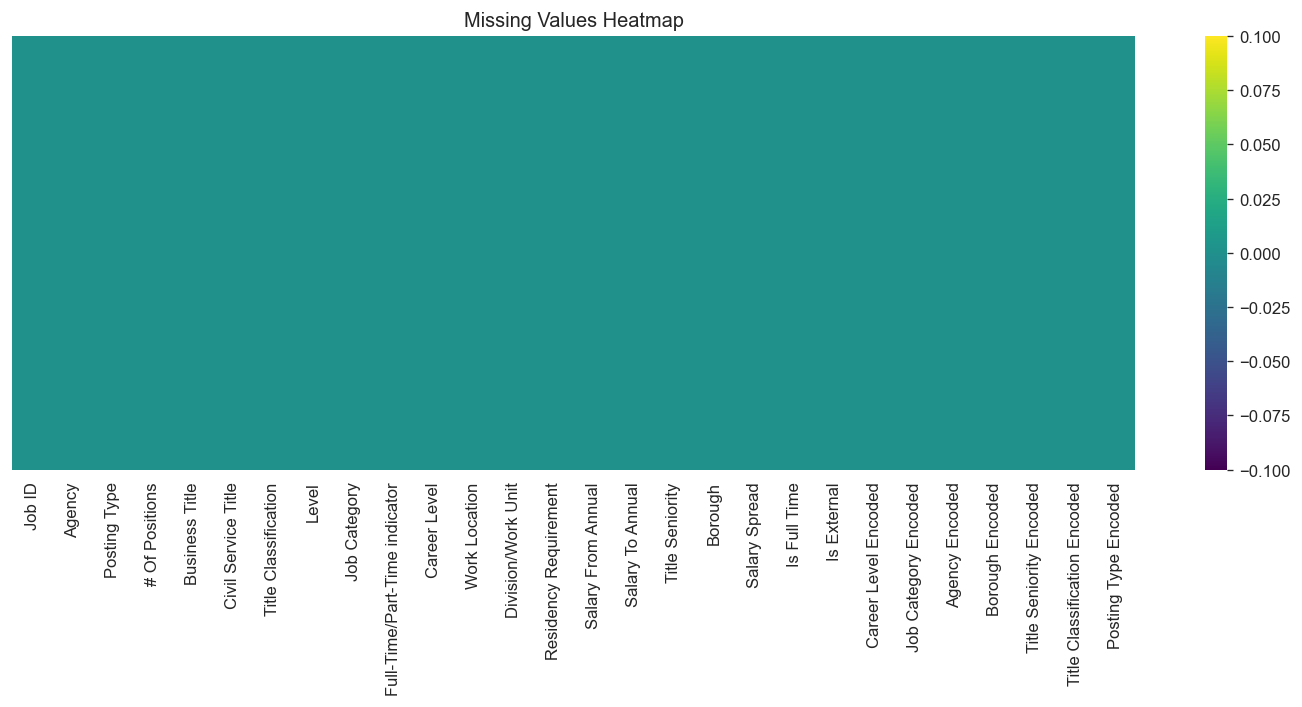

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\01_missing_values_heatmap.png


In [6]:
plt.figure(figsize=(12, 6))
sns.heatmap(_df.isnull(), cmap="viridis", cbar=True, yticklabels=False)
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_missing_values_heatmap.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "01_missing_values_heatmap.png")

## 4. Duplicate Records

In [7]:
print("Duplicate Rows:", _df.duplicated().sum())

Duplicate Rows: 0


In [8]:
print("Duplicate Rows Before:", _df.duplicated().sum())
_df = _df.drop_duplicates()
print("Duplicate Rows After :", _df.duplicated().sum())
print("New Shape:", _df.shape)
_df.to_csv(CLEAN_DATA_PATH, index=False)
print("✓ Duplicates removed and dataset saved.")

Duplicate Rows Before: 0
Duplicate Rows After : 0
New Shape: (5074, 28)
✓ Duplicates removed and dataset saved.


## 5. Numerical Columns Analysis

In [9]:
num_cols = _df.select_dtypes(include=np.number).columns.tolist()
print(num_cols)

['Job ID', '# Of Positions', 'Salary From Annual', 'Salary To Annual', 'Salary Spread', 'Is Full Time', 'Is External', 'Career Level Encoded', 'Job Category Encoded', 'Agency Encoded', 'Borough Encoded', 'Title Seniority Encoded', 'Title Classification Encoded', 'Posting Type Encoded']


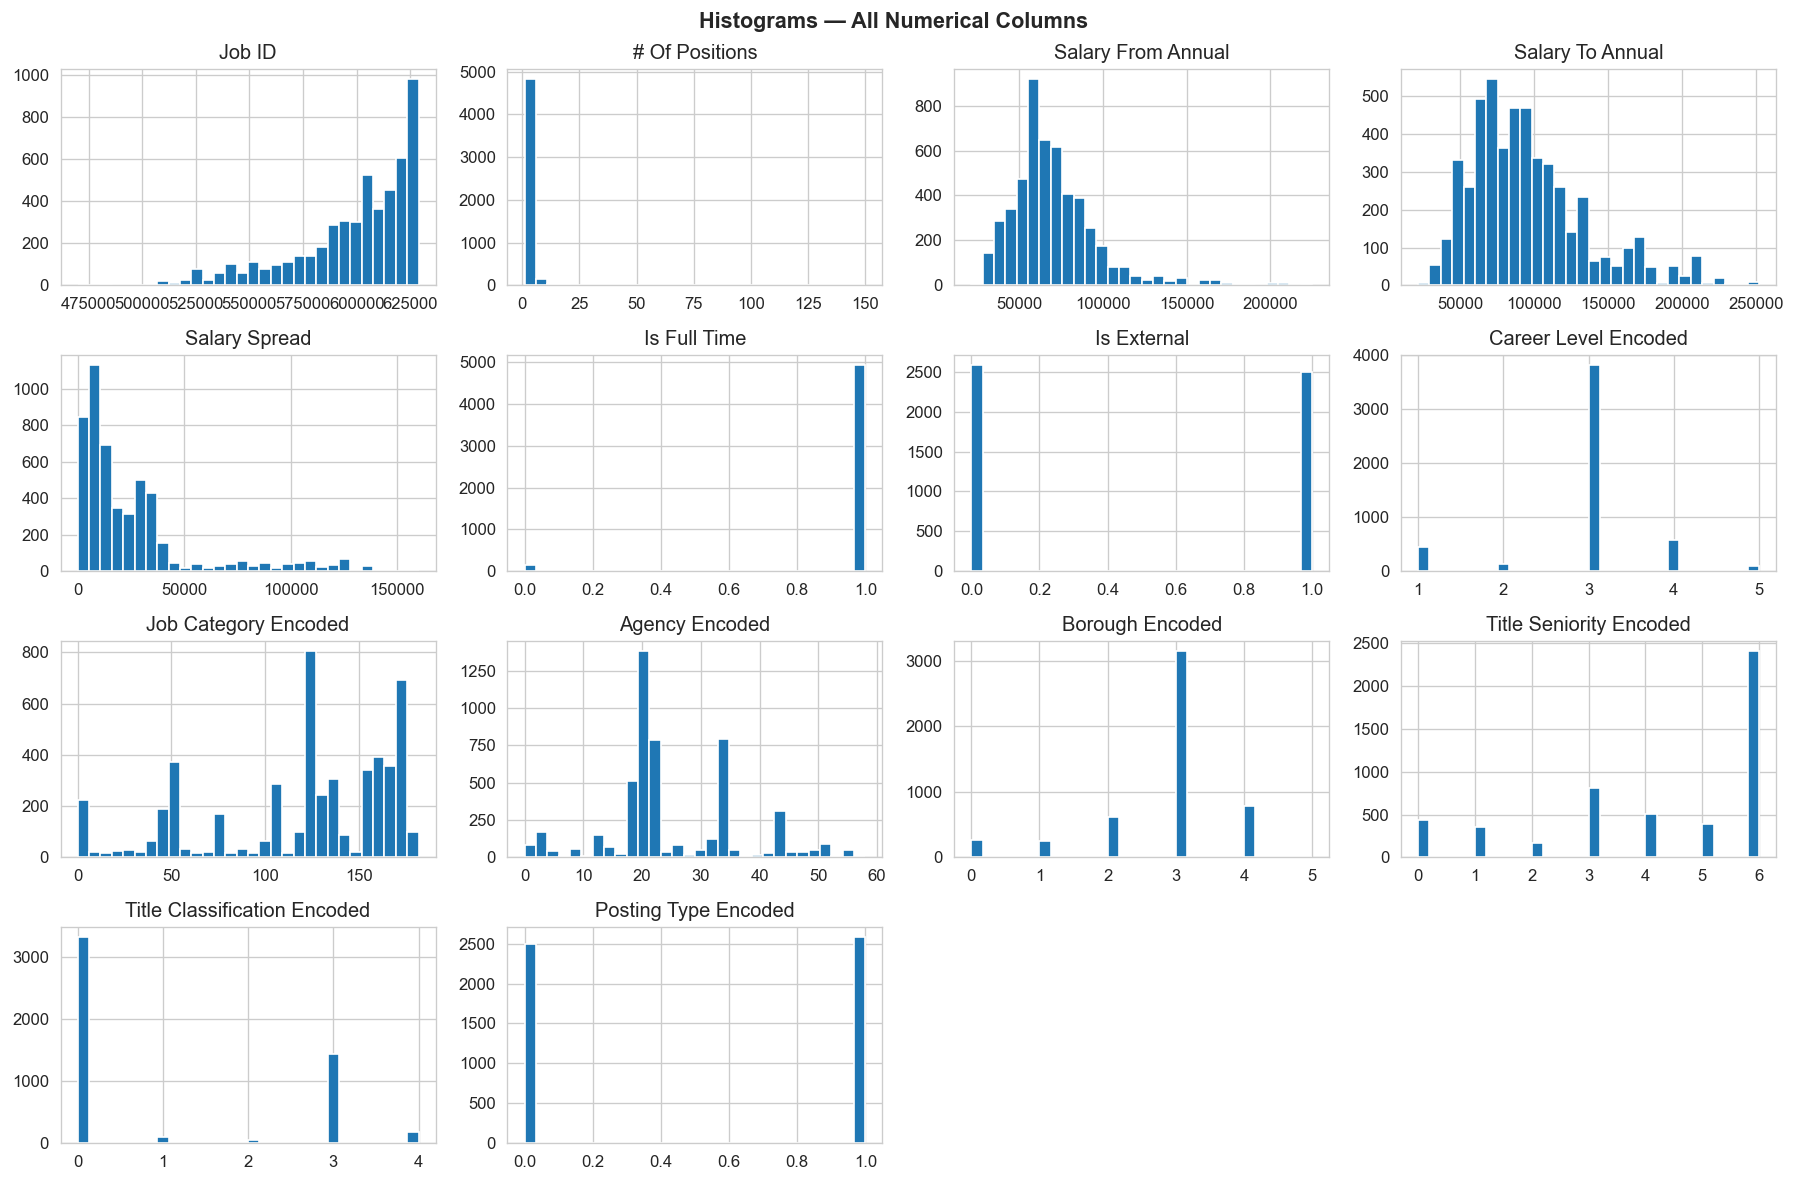

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\02_numerical_histograms.png


In [10]:
_df[num_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms — All Numerical Columns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_numerical_histograms.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "02_numerical_histograms.png")

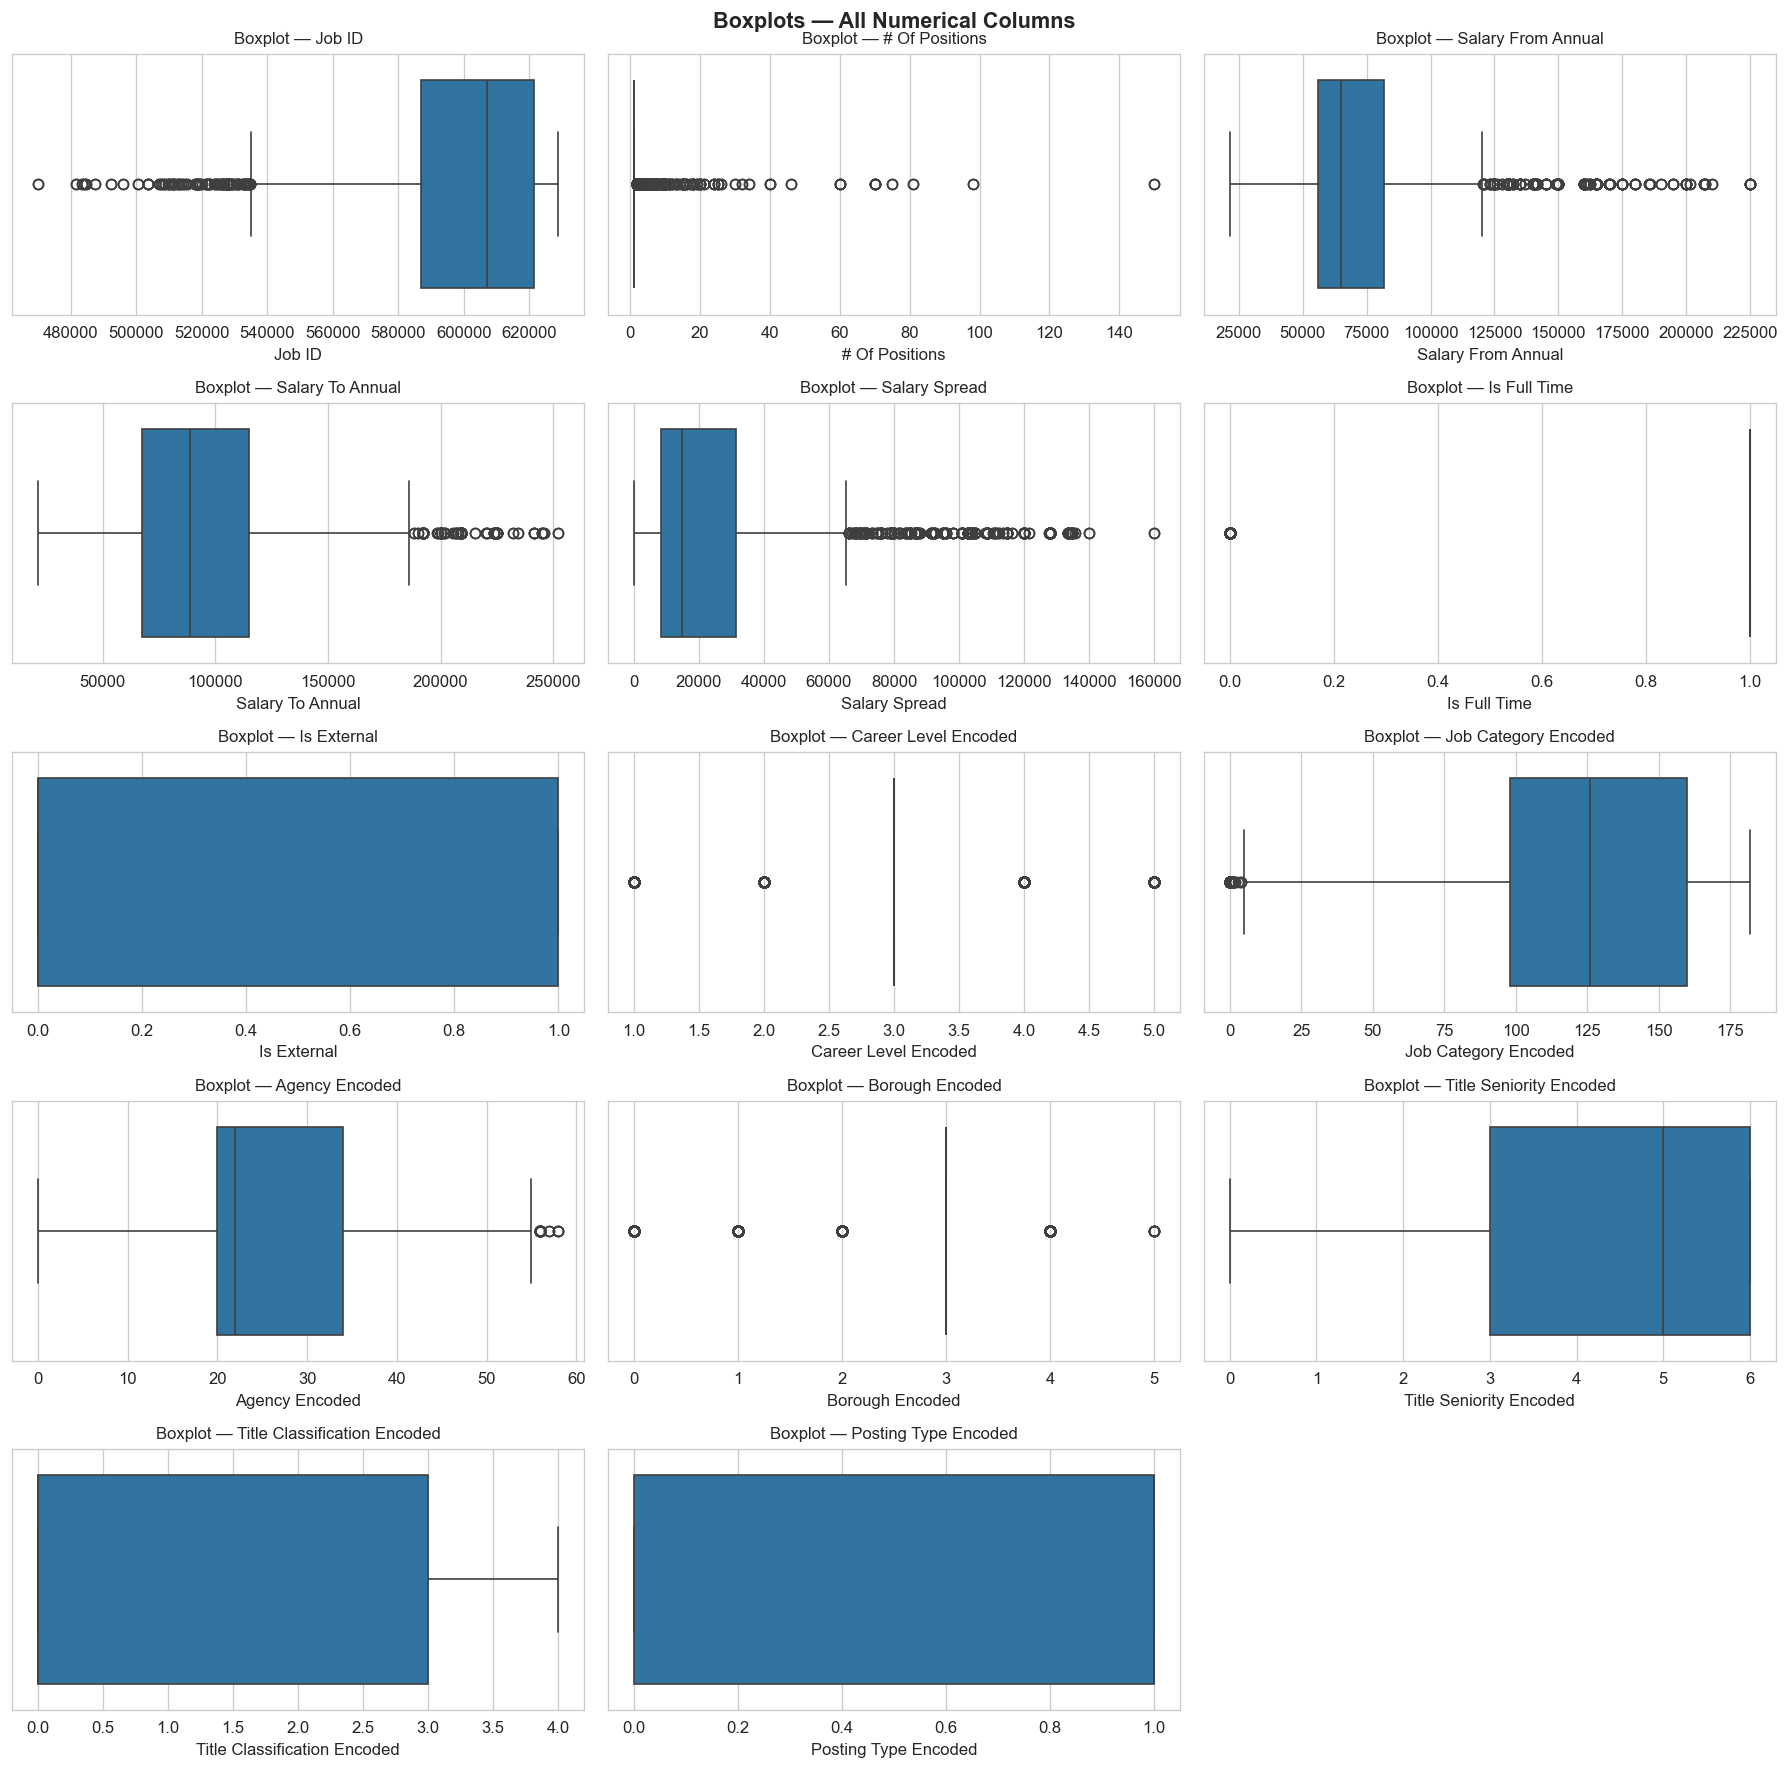

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\03_numerical_boxplots.png


In [11]:
n = len(num_cols)
fig, axes = plt.subplots(nrows=(n + 2) // 3, ncols=3, figsize=(15, (n // 3 + 1) * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(x=_df[col], ax=axes[i])
    axes[i].set_title(f"Boxplot — {col}", fontsize=10)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots — All Numerical Columns", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_numerical_boxplots.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "03_numerical_boxplots.png")

## 6. Correlation Analysis

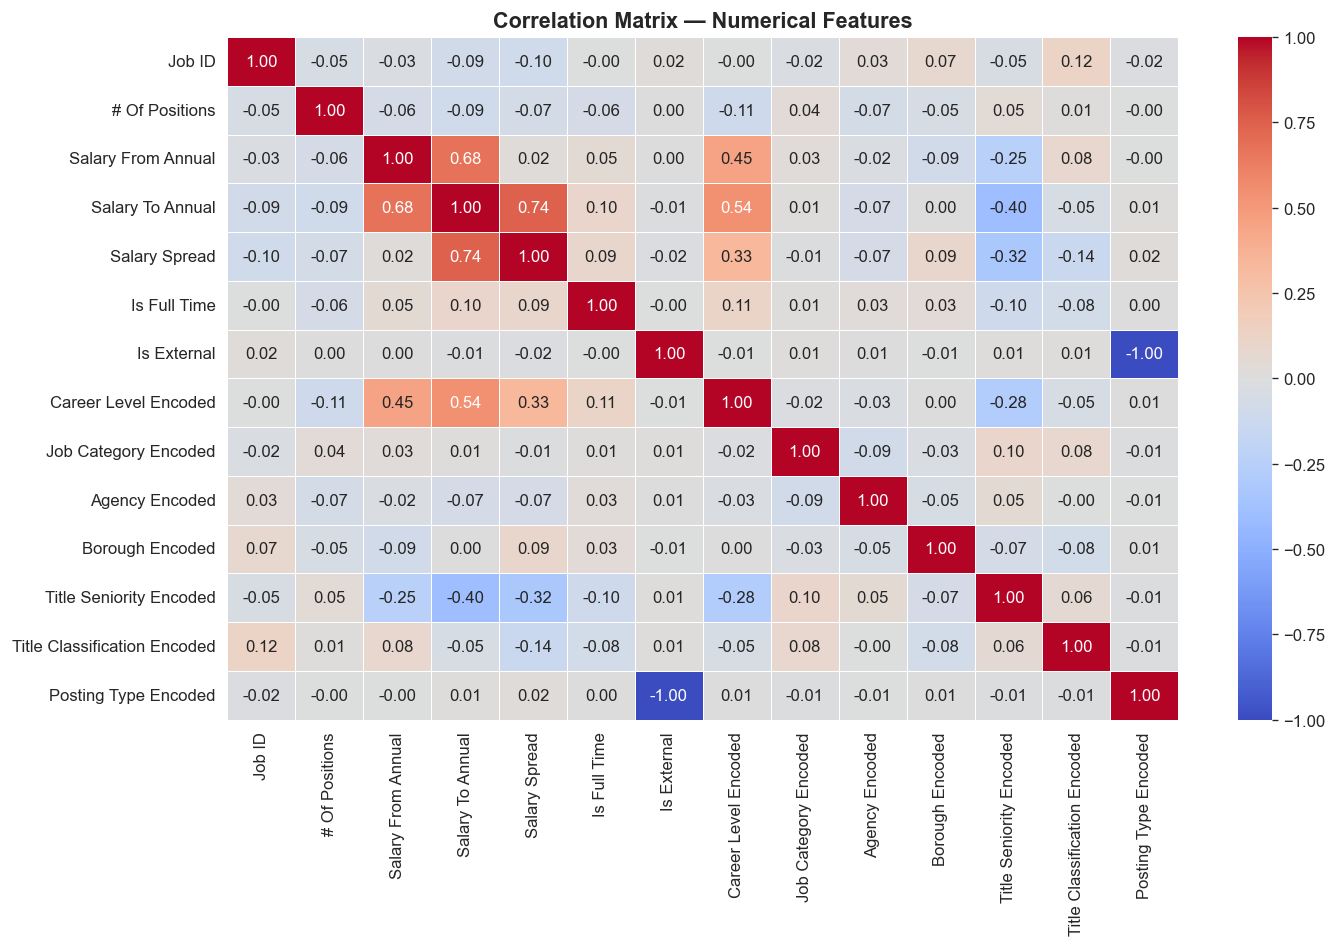

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\04_correlation_matrix.png


In [12]:
corr = _df[num_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix — Numerical Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_correlation_matrix.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "04_correlation_matrix.png")

## 7. Categorical Columns Analysis

In [13]:
cat_cols = _df.select_dtypes(include="object").columns.tolist()
print(cat_cols)

['Agency', 'Posting Type', 'Business Title', 'Civil Service Title', 'Title Classification', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Work Location', 'Division/Work Unit', 'Residency Requirement', 'Title Seniority', 'Borough']


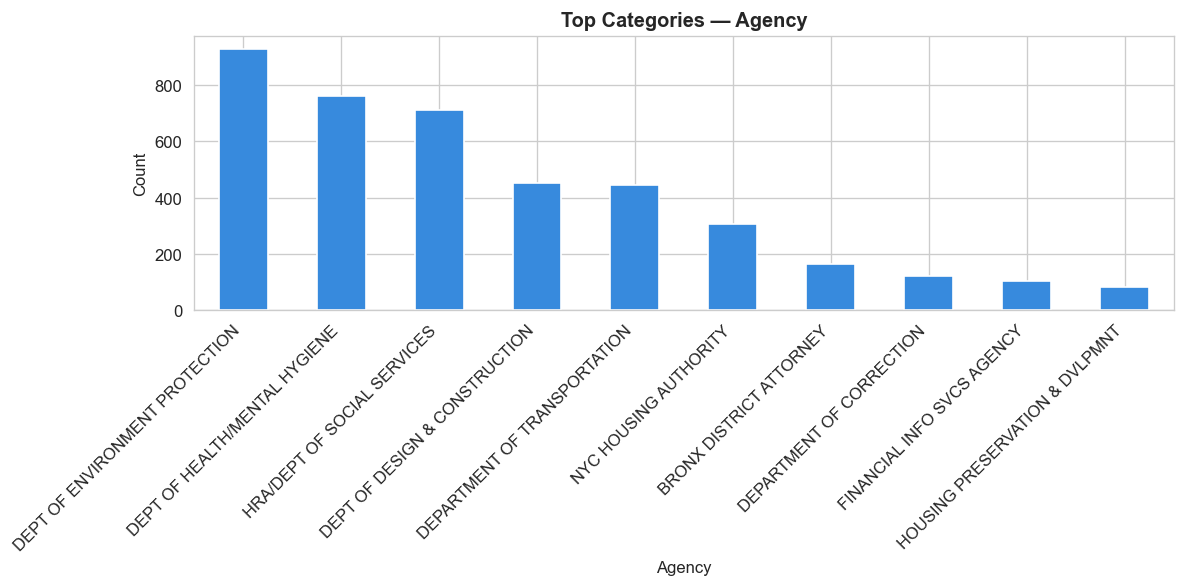

✓ Saved: 05_cat_agency.png


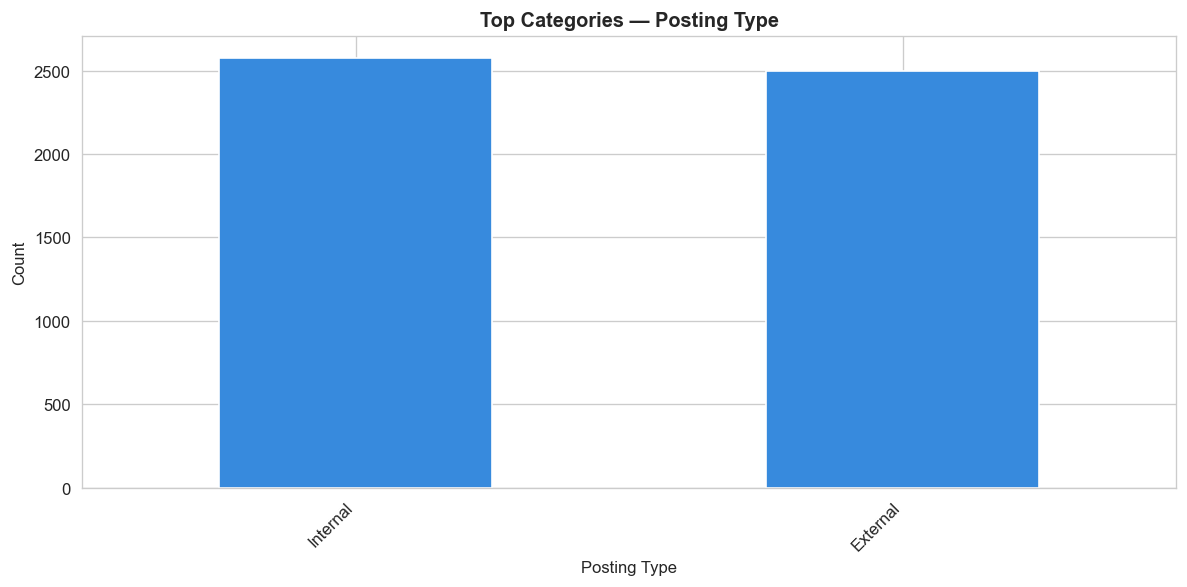

✓ Saved: 05_cat_posting_type.png


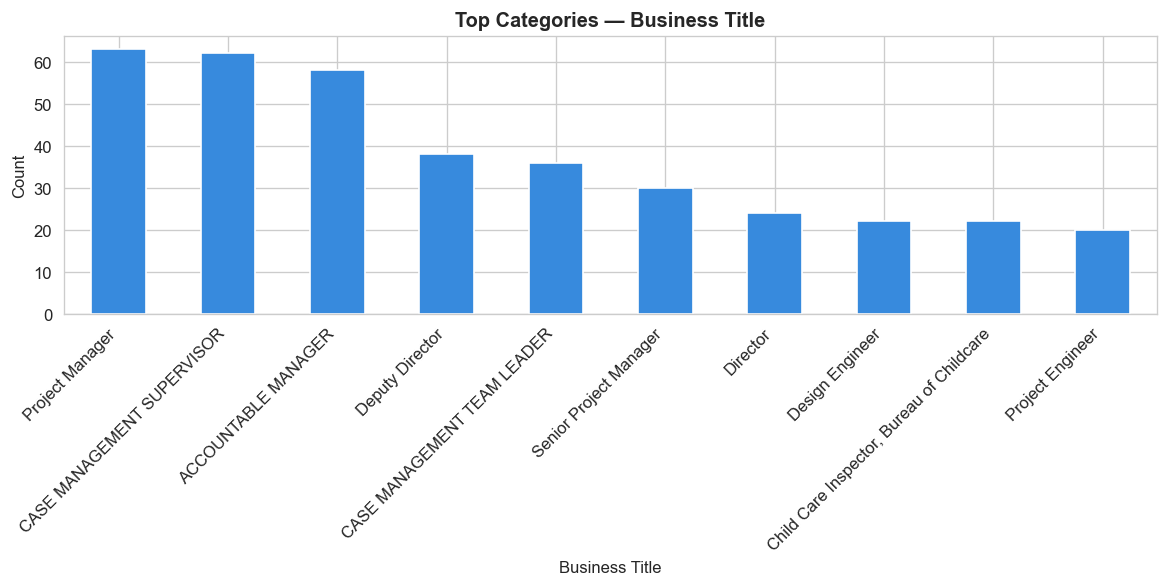

✓ Saved: 05_cat_business_title.png


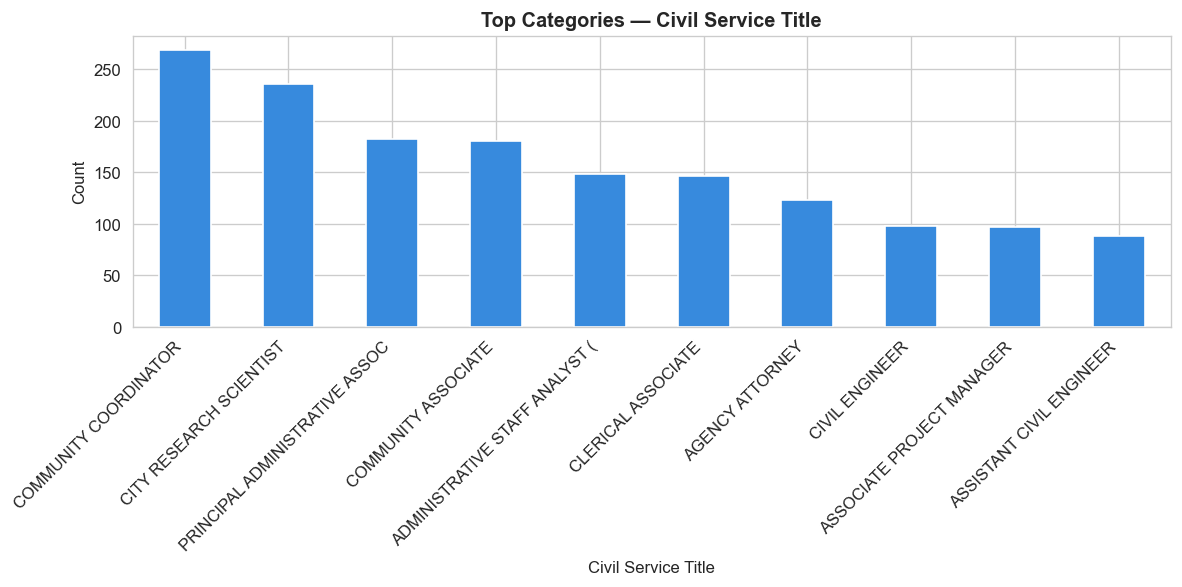

✓ Saved: 05_cat_civil_service_title.png


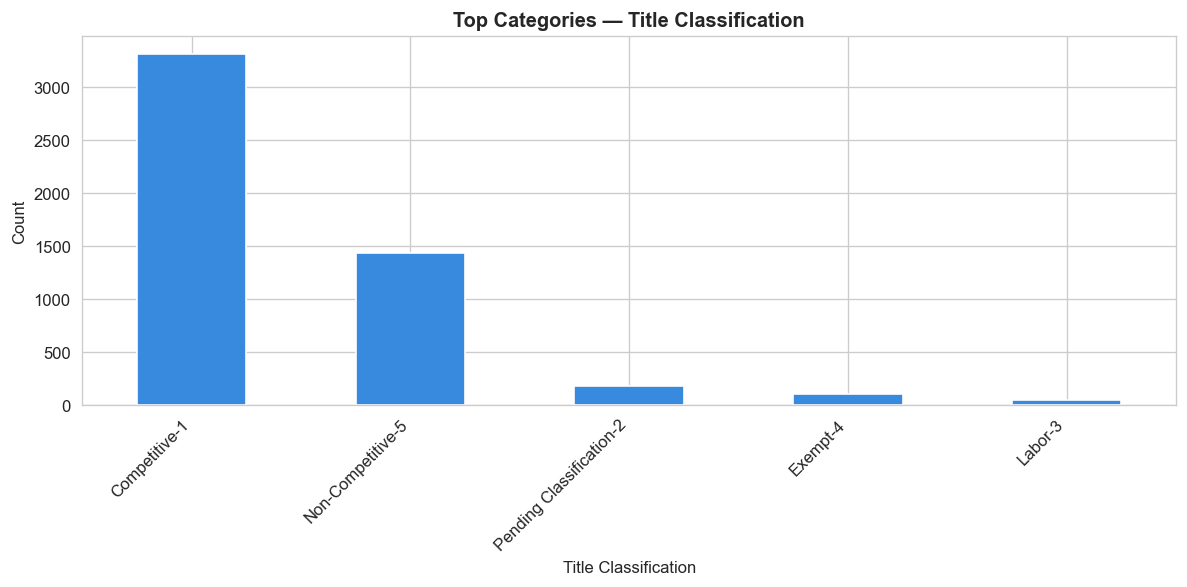

✓ Saved: 05_cat_title_classification.png


In [14]:
for col in cat_cols[:5]:
    plt.figure(figsize=(10, 5))
    _df[col].value_counts().head(10).plot(kind="bar", color="#378ADD", edgecolor="white")
    plt.title(f"Top Categories — {col}", fontsize=12, fontweight="bold")
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.tight_layout()
    safe_name = col.lower().replace(" ", "_").replace("/", "_")
    plt.savefig(OUTPUT_DIR / f"05_cat_{safe_name}.png")
    plt.show()
    print(f"✓ Saved: 05_cat_{safe_name}.png")

## 8. Salary Analysis
### 8.1 Salary To Annual Distribution

In [15]:
_df["Salary To Annual"] = pd.to_numeric(
    _df["Salary To Annual"].astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip(),
    errors="coerce"
)

print("dtype :", _df["Salary To Annual"].dtype)
print("Missing:", _df["Salary To Annual"].isnull().sum())
print(_df["Salary To Annual"].head())

dtype : float64
Missing: 0
0     94882.0
1    134570.0
2     91405.0
3     82730.0
4    106146.0
Name: Salary To Annual, dtype: float64


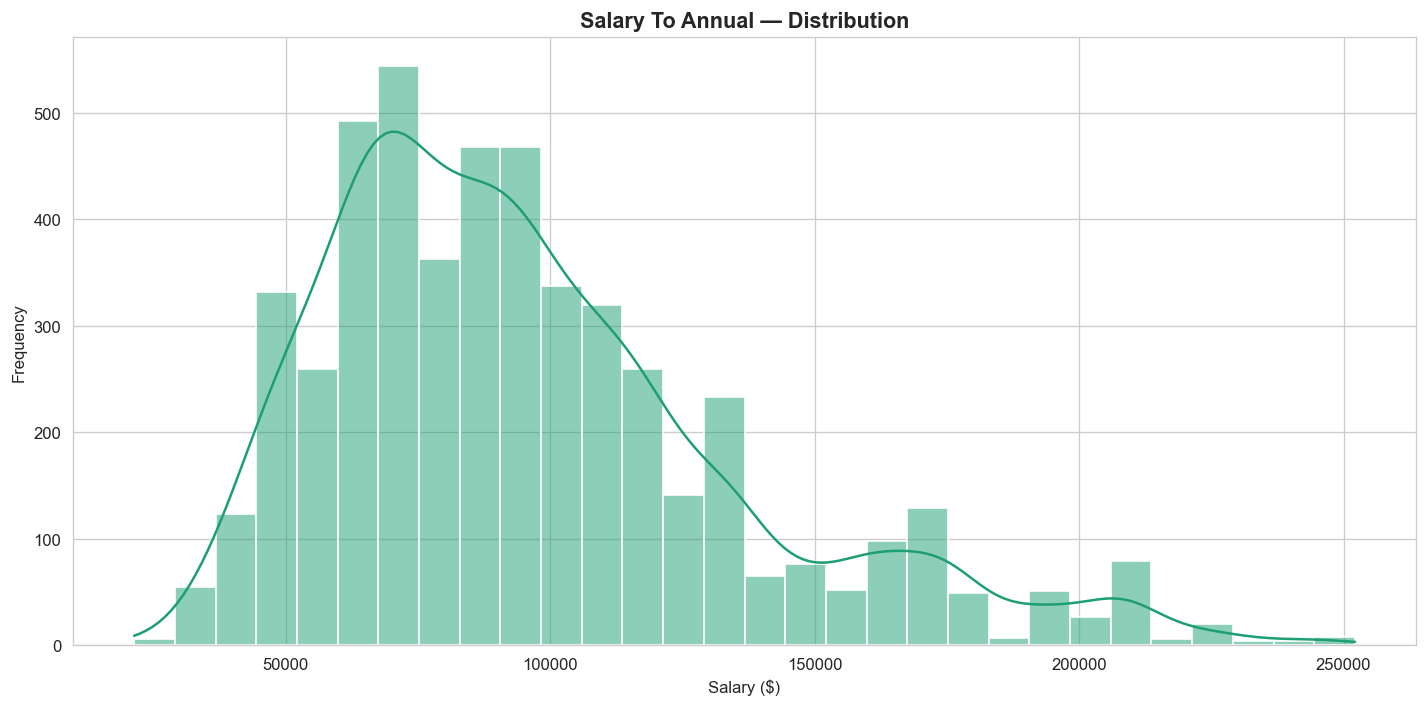

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\06_salary_to_distribution.png


In [16]:
plt.figure(figsize=(12, 6))
sns.histplot(_df["Salary To Annual"].dropna(), bins=30, kde=True, color="#1D9E75")
plt.title("Salary To Annual — Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Salary ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_salary_to_distribution.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "06_salary_to_distribution.png")

### 8.2 Average Salary Distribution

In [17]:
for col in ["Salary From Annual", "Salary To Annual"]:
    _df[col] = pd.to_numeric(
        _df[col].astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip(),
        errors="coerce"
    )

_df["Average Salary"] = (_df["Salary From Annual"] + _df["Salary To Annual"]) / 2

print(_df[["Salary From Annual", "Salary To Annual", "Average Salary"]].head())

   Salary From Annual  Salary To Annual  Average Salary
0             82506.0           94882.0         88694.0
1             58682.0          134570.0         96626.0
2             58682.0           91405.0         75043.5
3             50972.0           82730.0         66851.0
4             92301.0          106146.0         99223.5


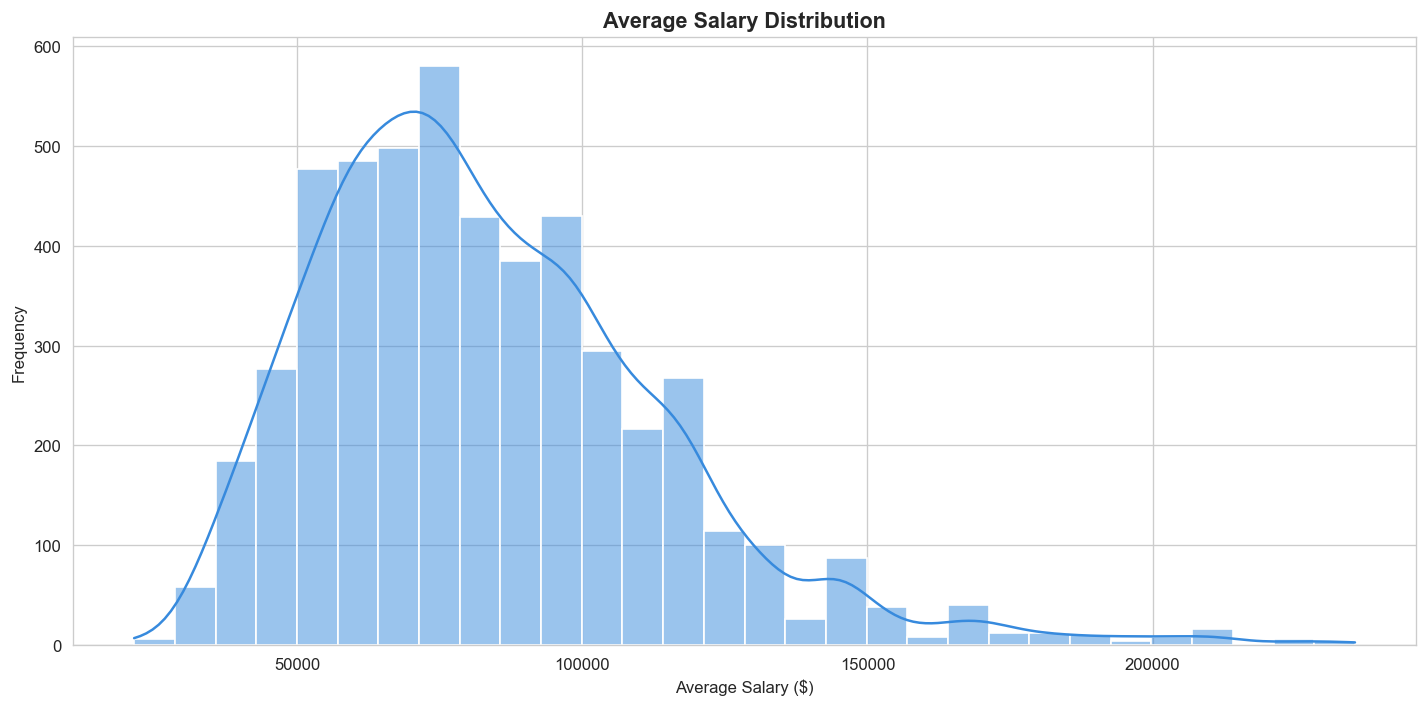

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\07_average_salary_distribution.png


In [18]:
plt.figure(figsize=(12, 6))
sns.histplot(_df["Average Salary"].dropna(), bins=30, kde=True, color="#378ADD")
plt.title("Average Salary Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Average Salary ($)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "07_average_salary_distribution.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "07_average_salary_distribution.png")

### 8.3 Salary From vs Salary To

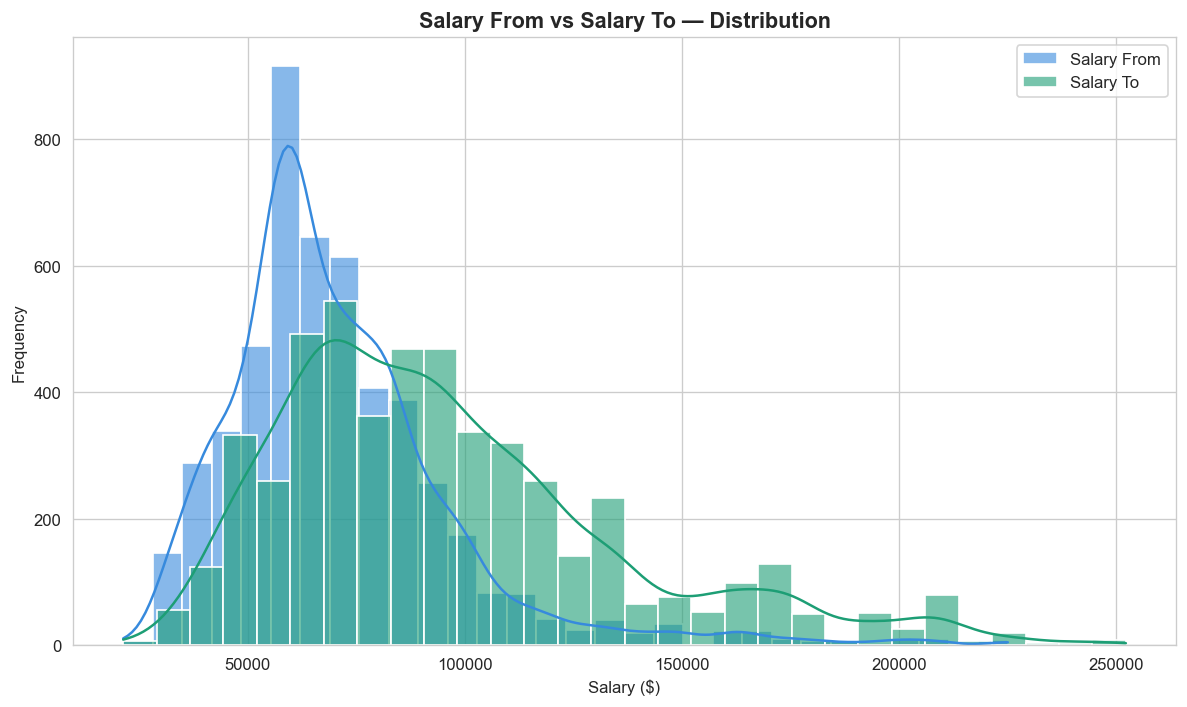

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\08_salary_from_vs_to_distribution.png


In [19]:
plt.figure(figsize=(10, 6))
sns.histplot(_df["Salary From Annual"].dropna(), bins=30, kde=True,
             color="#378ADD", label="Salary From", alpha=0.6)
sns.histplot(_df["Salary To Annual"].dropna(), bins=30, kde=True,
             color="#1D9E75", label="Salary To", alpha=0.6)
plt.title("Salary From vs Salary To — Distribution", fontsize=13, fontweight="bold")
plt.xlabel("Salary ($)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "08_salary_from_vs_to_distribution.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "08_salary_from_vs_to_distribution.png")

## 9. Outlier Detection

In [20]:
num_cols = _df.select_dtypes(include='number').columns.tolist()
print("Numerical Columns:", num_cols)

Numerical Columns: ['Job ID', '# Of Positions', 'Salary From Annual', 'Salary To Annual', 'Salary Spread', 'Is Full Time', 'Is External', 'Career Level Encoded', 'Job Category Encoded', 'Agency Encoded', 'Borough Encoded', 'Title Seniority Encoded', 'Title Classification Encoded', 'Posting Type Encoded', 'Average Salary']


In [21]:
outlier_summary = []
for col in num_cols:
    Q1 = _df[col].quantile(0.25)
    Q3 = _df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = len(_df[(_df[col] < lower) | (_df[col] > upper)])
    outlier_summary.append({"Column": col, "Outliers": n_out,
                             "Lower Bound": round(lower, 2), "Upper Bound": round(upper, 2)})
    print(f"  {col:40s}: {n_out} outliers")

outlier_df = pd.DataFrame(outlier_summary).set_index("Column")
outlier_df

  Job ID                                  : 196 outliers
  # Of Positions                          : 1011 outliers
  Salary From Annual                      : 222 outliers
  Salary To Annual                        : 202 outliers
  Salary Spread                           : 521 outliers
  Is Full Time                            : 162 outliers
  Is External                             : 0 outliers
  Career Level Encoded                    : 1264 outliers
  Job Category Encoded                    : 218 outliers
  Agency Encoded                          : 49 outliers
  Borough Encoded                         : 1932 outliers
  Title Seniority Encoded                 : 0 outliers
  Title Classification Encoded            : 0 outliers
  Posting Type Encoded                    : 0 outliers
  Average Salary                          : 120 outliers


,Outliers,Lower Bound,Upper Bound
Column,,,
Job ID,196,534854.00,673288.00
# Of Positions,1011,1.00,1.00
Salary From Annual,222,17183.50,120203.50
Salary To Annual,202,-3200.62,185920.38
Salary Spread,521,-25972.50,65759.50
Is Full Time,162,1.00,1.00
Is External,0,-1.50,2.50
Career Level Encoded,1264,3.00,3.00
Job Category Encoded,218,5.00,253.00


## 10. Target Variable Analysis

In [22]:
if "Average Salary" in _df.columns:
    print(_df["Average Salary"].describe())

count      5074.000000
mean      83446.568217
std       30543.601723
min       21379.800000
25%       61331.000000
50%       77978.500000
75%       99743.875000
max      235500.000000
Name: Average Salary, dtype: float64


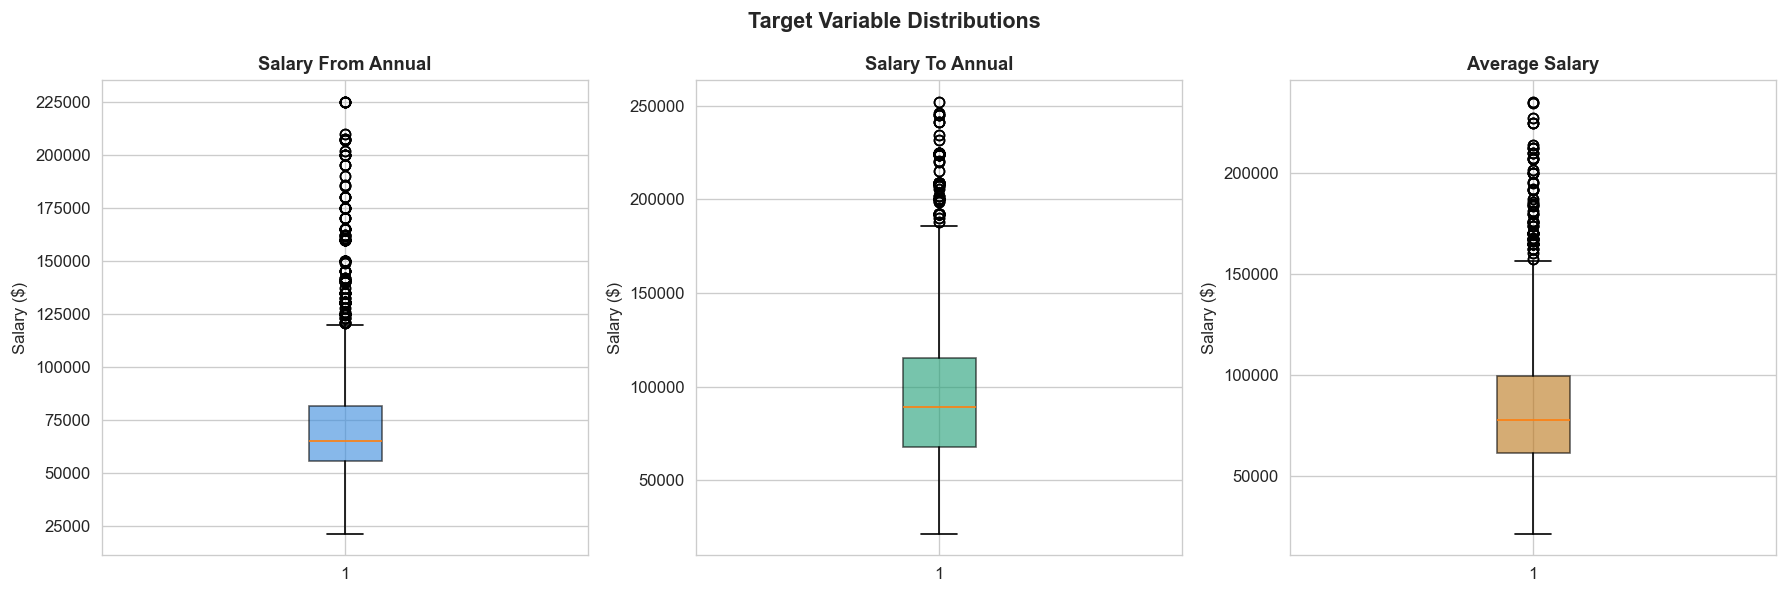

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\09_target_variable_boxplots.png


In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, color in zip(axes,
    ["Salary From Annual", "Salary To Annual", "Average Salary"],
    ["#378ADD", "#1D9E75", "#BA7517"]):
    ax.boxplot(_df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_ylabel("Salary ($)")

plt.suptitle("Target Variable Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "09_target_variable_boxplots.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "09_target_variable_boxplots.png")

## 11. Feature Relationships

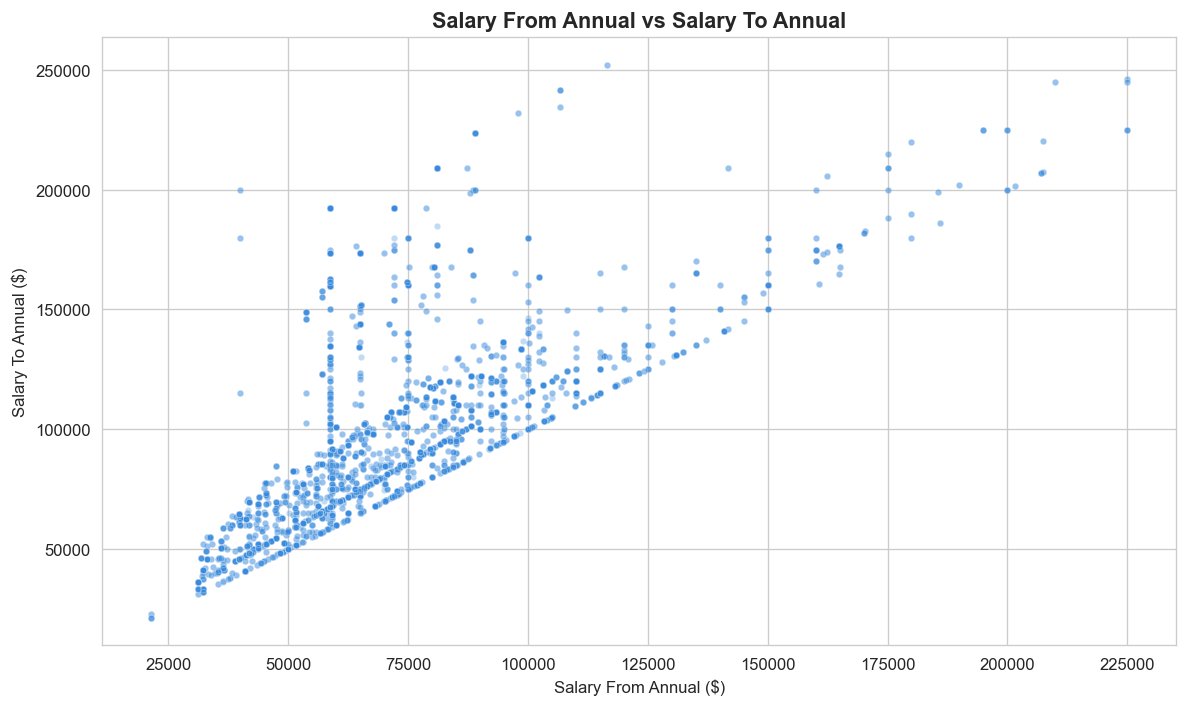

✓ Saved: D:\study_material\ProjectFinal\salary_range_prediction\eda_outputs\cleaned\10_salary_from_vs_to_scatter.png


In [24]:
scatter_df = _df.dropna(subset=["Salary From Annual", "Salary To Annual"])

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x="Salary From Annual",
                y="Salary To Annual", alpha=0.3, s=15, color="#378ADD")
plt.title("Salary From Annual vs Salary To Annual", fontsize=13, fontweight="bold")
plt.xlabel("Salary From Annual ($)")
plt.ylabel("Salary To Annual ($)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "10_salary_from_vs_to_scatter.png")
plt.show()
print("✓ Saved:", OUTPUT_DIR / "10_salary_from_vs_to_scatter.png")

## ✅ EDA on Cleaned Data Complete
All charts saved to `eda_outputs/cleaned/`

**→ Next step: Run `04_modeling.ipynb`**